# 목차
2. 딥러닝 논문의 구조
딥러닝 논문이 어떻게 구성되어있는지 알아봅니다.
3. ResNet의 핵심 개념과 그 효과
ResNet의 문제의식과 핵심 개념인 Residual Block을 알아봅니다.
4. ResNet 이후 시도 (1) Connection을 촘촘히
DesNet을 알아봅니다.
5. ResNet 이후 시도 (2) 어떤 특성이 중요할까?
SENet을 알아봅니다.
6. 모델 최적화하기 (1) Neural Architecture Search
NASNet을 알아봅니다.
7. 모델 최적화하기 (2) EfficientNet
EfficientNet을 알아봅니다.
8. 직접 찾아보기
딥러닝 논문을 직접 찾아봅니다.
학습 목표
딥러닝 논문의 구조를 설명할 수 있습니다.
CNNs 구조 (architecture)의 발전과정을 설명할 수 있습니다.
새로 나온 딥러닝 논문을 찾아볼 수 있습니다.

# 논문 형식적 구조
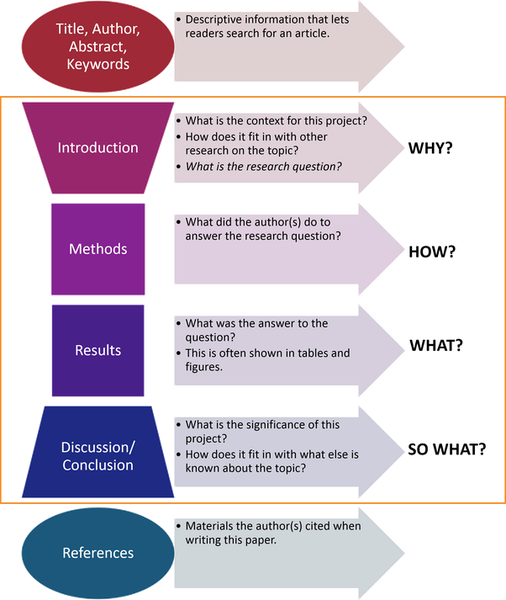

초록(abstract) 은 논문의 요약으로 핵심 아이디어와 논문이 기여하는 점을 포함합니다. 그 뒤로 논문의 주요 내용이 따라오는데요. 논문 내용은 일반적으로 서론(introduction) 과 관련 연구(related work) , 그리고 제안하는 방법에 관한 이론 설명 이 따라옵니다. 이렇게 제안하는 방법을 소개한 후 이 효과를 확인하기 위한 실험(experiments) 환경과 결과로 구성됩니다. 그 뒤는 결론(conclusion) 으로 전체 논문의 요약과 향후 연구 방향을 소개하기도 합니다.

논문의 내용이 끝나면 뒤로는 참고문헌(reference) 이 나오고 때에 따라서 부록(appendix) 을 첨부하는 경우도 있습니다. 참고문헌에서는 논문의 설명과 구현에 있어 인용한 논문들의 리스트가 소개되고 부록에서는 미처 본문에서 설명하지 못한 구현 또는 추가적인 실험 설명이 포함됩니다.

이러한 논문의 형식 속에 담고자 하는 논리 구조가 있습니다.

1. 이전까지의 연구가 해결하지 못했던 문제의식
2. 이 문제를 해결하기 위한 그동안의 다른 시도들
3. 문제해결을 위한 이 논문만의 독창적인 시도
4. 그러한 시도가 가져온 차별화된 성과

서론(Introduction)은 전체 논문의 논리구조를 명확하게 정리하여 제시하는 중요한 역할을 담당하고 있습니다. 이후 관련 연구(Related Work)는 주로 2)의 내용을, 논문의 본론과 실험(Experiments)가 3)의 내용을, Experiment에 포함된 실험 결과와 해석이 4)의 내용을 구체화하여 제시하는 역할을 합니다.

이렇게 작성된 논문은 후속 연구를 진행하는 새로운 논문에 인용됩니다. 새로운 논문에서는 인용된 논문의 한계점을 새로운 문제의식으로 삼아 더 나은 방법과 이론을 제안합니다. 이렇게 문제들이 해결되고 개선되는 과정이 거듭되면서 수 많은 논문들로 이루어진 거대한 생각의 족보를 만들어가게 됩니다. 따라서 논문을 보면서 단순히 그 논문의 내용을 이해하는 것 자체가 중요하기도 하지만, 그 논문이 가지는 역사적인 의의와 그 논문이 처음 제시했던 독창적인 아이디어가 무엇인지를 파악하는 것도 중요합니다.

# ResNet의 핵심개념과 그 효과
1) ResNet 논문의 문제의식
서론(Introduction)을 통해 ResNet 논문이 제기하고 있는 문제의 핵심을 명확히 정리해 봅시다. 최초로 제기하는 질문은 딥러닝 모델의 레이어를 깊이 쌓으면 항상 성능이 좋아지는가 하는 것입니다. 그러나 이 질문이 문제의 핵심은 아닙니다. 레이어를 깊이 쌓았을 때 Vanishing/Exploding Gradient 문제가 발생하여 모델의 수렴을 방해하는 문제가 생기는데, 여기에 대해서는 이미 몇 가지 대응 방법이 알려져 있기 때문입니다.
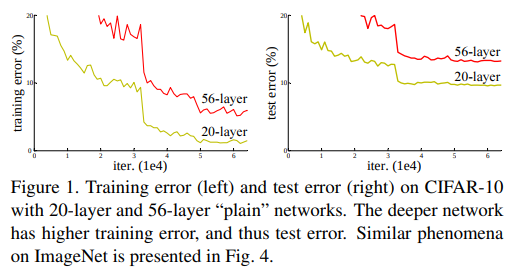


# 서론 (Introduction) 요약
포인트 1 (네트워크 깊이의 중요성): 이미지 분류 및 다양한 시각 인식 작업에서 신경망의 '깊이(Depth)'는 성능 향상의 핵심 요소입니다. VGG Net 등 최근 연구들은 수십 층에 달하는 매우 깊은 모델을 활용해 뛰어난 성과를 거두었습니다.

포인트 2 (기존의 장애물과 해결책): "층을 더 쌓기만 하면 더 좋은 네트워크가 될까?"라는 의문이 제기되었습니다. 과거에는 층이 깊어질수록 레이어의 기울기가 사라지거나 폭발하는 그라디언트 소실/폭발(Vanishing/Exploding Gradients) 문제가 있었으나, 이는 적절한 가중치 초기화(Normalized Initialization)와 배치 정규화(BatchNorm) 같은 중간 정규화 레이어 덕분에 어느 정도 해결되어 수십 개의 층도 역전파를 통해 수렴(Convergence)을 시작할 수 있게 되었습니다.

포인트 3 (새로운 문제와 제안): 하지만 네트워크가 수렴할 수 있게 되었음에도 불구하고, 깊이가 일정 수준을 넘어서면 정확도가 포화되었다가 급격히 떨어지는 열화 문제(Degradation Problem)가 발생합니다. 저자들은 이 문제를 해결하기 위해 쌓여진 레이어들이 직접 원래의 매핑을 학습하는 대신, 잔차 매핑(Residual Mapping)을 학습하도록 재구성한 'Deep Residual Learning' 프레임워크(ResNet)를 제안합니다.

# 열화 문제 (Degradation Problem) 란?  

열화 문제(Degradation Problem)는 딥러닝 모델의 층(Depth)이 깊어질 때, 과적합(Overfitting)이 아님에도 불구하고 오히려 훈련 오차(Training Error)와 테스트 오차(Test Error)가 모두 높아지는 현상을 말합니다.

# ResNet 논문이 제시한 솔루션 : Residual Block
ResNet은 깊은 네트워크의 학습이 어려운 점을 해결하기 위해서 레이어의 입력값을 활용하여 레이어가 "residual function"(잔차 함수)을 학습하도록 합니다.

위 문구는 논문 초록의 설명을 개략적으로 번역한 말이라 어렵게 들리실 수 있을 것 같습니다. 단순히 말하자면 일종의 지름길("shortcut connection")을 통해서 레이어가 입력값을 직접 참조하도록 레이어를 변경했다고 보시면 됩니다. Shortcut connection은 앞에서 입력으로 들어온 값을 네트워크의 출력층에 곧바로 더해줍니다. 네트워크는 출력값에서 원본 입력을 제외한 잔차(residual) 함수를 학습하기 때문에 네트워크가 ResNet이라는 이름을 가지게 되었습니다.

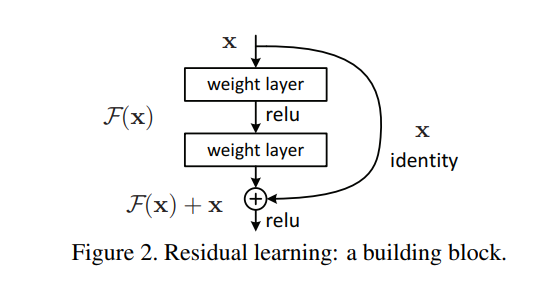

레이어를 많이 쌓았다고 해서 모델 성능이 떨어지는 것을 어떻게 설명해야 할까요? 저자들은 이 부분에 의문을 품었습니다. 만약 기존 모델에다가 identity mapping 레이어를 수십 장 덧붙인다고 해서 모델 성능이 떨어질 리는 없을 텐데, 그렇다면 레이어를 많이 쌓았을 때 이 레이어들은 오히려 identity mapping 레이어보다도 못하다는 뜻이 됩니다. 많이 겹쳐 쌓은 레이어가 제대로 학습이 이루어지지 않았다는 반증이 됩니다.

여기서 저자들이 기발한 생각을 합니다. 학습해야 할 레이어 H(x)를 F(x)+x로 만들면 어떨까? 여기서 x는 레이어의 입력값입니다. 그렇다면 설령 F(x)가 Vanishing Gradient현상으로 전혀 학습이 안되어 zero mapping이 될지라도, 최종 H(x)는 최소한 identity mapping이라도 될 테니 성능 저하는 발생하지 않게 된다는 것입니다. 그렇다면 실제로 학습해야 할 F(x)는 학습해야 할 레이어 H(x)에다 입력값 x를 뺀 형태, 즉 잔차(Residual)함수가 되는데, 이것은 H(x)를 직접 학습하는 것보다는 훨씬 학습이 쉽지 않겠냐는 것입니다. 레이어를 깊이 쌓을수록 Residual에 해당하는 F(x)는 0에 가까운 작은 값으로 수렴해도 충분하기 때문입니다. 그리고 실험해 보니 이 구조가 실제로도 안정적으로 학습이 되며, 레이어를 깊이 쌓을수록 성능이 향상되는 것이 확인되었기 때문입니다.

정리하자면, Residual 레이어를 F(x)로 표현하면 이 레이어의 결과는 입력값 x에 대해 F(x)가 됩니다. 여기에 레이어의 입력값 x을 더해주면 최종 출력값은 F(x)+x, 즉 우리가 보통 생각하는 레이어의 결괏값이 되겠지요. 이후 이 값은 ReLU 활성함수(activation function)을 거치게 됩니다. 위 식에서 학습되어야 할 residual mapping으로서 잔차 학습(residual learning)은 이 식을 학습합니다. ResNet에서는 shortcut connection을 가진 ResNet의 기본 블록을 Residual Block이라고 부릅니다. ResNet은 이러한 Residual Block 여러 개로 이루어집니다.

이러한 shortcut connection의 아이디어는 다양한 레이어에 적용 가능하기 때문에 이후 나온 여러 네트워크 아키텍처에서 활용됩니다.

# Experment
간략히 살펴보셨다시피 딥러닝 논문에서는 모델의 설계를 설명한 뒤 모델을 실제로 구현해 그 효과를 입증합니다. ResNet을 예시로 논문의 실험(experiments) 부분을 조금 더 자세히 살펴봅시다.

ResNet에 추가된 shortcut connection의 아이디어를 검증하려면 어떤 실험을 해야 할까요? 당연히 shortcut connection이 없는 네트워크와 이를 사용한 네트워크를 가지고 성능을 비교해 봐야 할 것입니다.

실제 논문에서는 네트워크가 깊어짐에 따라 발생하는 경사소실(vanishing gradient) 문제를 ResNet이 해결함을 보여주기 위해서, shortcut connection의 유무와 네트워크 깊이에 다르게 한 4가지 모델을 구현합니다. 18개 층과 34개 층을 갖는 네트워크를, 각각 shortcut이 없는 일반 네트워크(plain network)와 shortcut이 있는 ResNet 두 가지로 구현해 총 4가지를 만든 것이지요. 이후 이미지넷(ImageNet) 데이터를 사용해 각 모델을 훈련을 시킨 뒤 효과를 분석합니다.
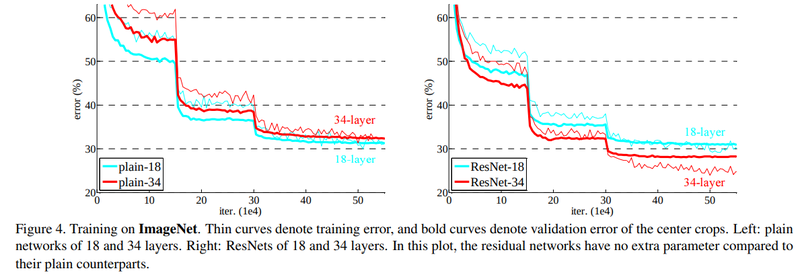

위 그림에서 왼쪽은 일반 네트워크 두 개로 네트워크가 깊어지더라도 학습이 잘되지 않는 것을 볼 수 있습니다. 34개 층을 갖는 네트워크가 18개 층을 갖는 네트워크보다 오류율(error rate)이 높지요. 하지만 shortcut이 적용된 오른쪽에서는 레이어가 깊어져도 학습이 잘 되는 효과를 볼 수 있습니다. 그렇다면 이렇게 학습된 모델은 검증 데이터셋(vallidation dataset)에서 어떻게 차이가 날까요?
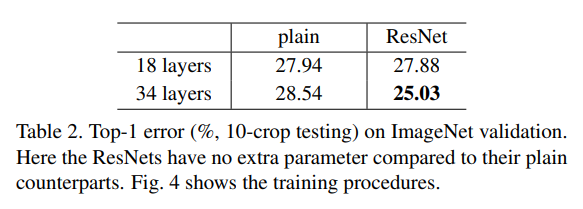

위 표는 이미지넷 검증 데이터셋을 사용해 실험한 결과를 나타냅니다. Top-1 error란 모델이 가장 높은 확률 값으로 예측한 class 1개가 정답과 일치하는지 보는 경우의 오류율입니다. Top-5는 모델이 예측한 값들 중 가장 높은 확률 값부터 순서대로 5개 class 중 정답이 있는지를 보는 것이지요. 이 숫자는 당연히 낮을수록 좋습니다.

일반 네트워크("plain")는 레이어가 16개나 늘어나 네트워크가 깊어졌는데도 오류율은 오히려 높아졌습니다. 경사소실로 인해 훈련이 잘되지 않았기 때문입니다. ResNet에서는 잘 훈련된 레이어가 16개 늘어난 효과로 오류율이 2.85% 감소했습니다. 논문에서는 이렇게 간단한 실험으로 Residual Block의 효과를 입증하고 있습니다.

# ResNet 이후 시도 (1) Connection을 촘촘히
ResNet이 보여준 실험 결과를 살펴보면서 "이 정도 성능이면 충분하지 않을까"라는 생각이 드셨을 수 있지만 아직 개선의 여지가 남아있습니다. Densely Connected Convolutional Networks , 줄여서 DenseNet 의 저자들은 ResNet의 shortcut connection을 마치 Fully Connected Layer처럼 촘촘히 가지도록 한다면 더욱 성능 개선 효과가 클 것이라고 생각하고 이를 실험으로 입증해 보였습니다.

1) Dense Connectivity
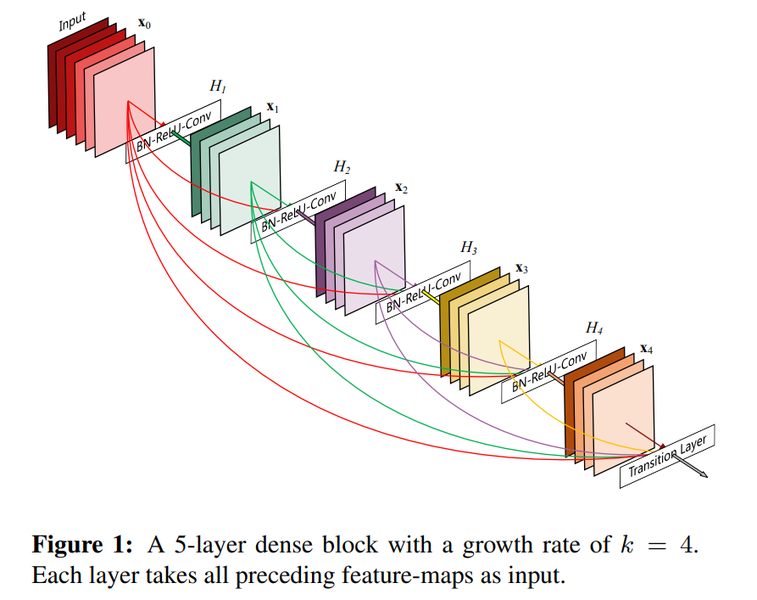

일반적인 컨볼루션 네트워크가 L개의 레이어에 대해 각 레이어 간 하나씩의 연결, 즉 총 L개의 연결을 갖는 것과는 달리, DenseNet의 기본 블록은 L 개의 레이어가 있을 때 레이어 간 L(L+1)/2 개의 직접적인 연결(direct connection)을 만듭니다. 이러한 연결 구조를 "dense connectivity" 라고 부르며, 아래처럼 표기하고 이를 합성함수(composite function)라고 부릅니다.
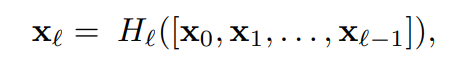

각 레이어는 이전 레이어들에서 나온 특성 맵(feature map) 전부를 입력값으로 받습니다. 위 식에서 은 0 번째 레이어를 거친 특성 맵부터 l−1 번째 레이어를 거친 특성 맵까지를 의미하며, 이들은 합성함수 H를 거쳐 l 번째 레이어의 출력값이 됩니다. DenseNet은 이를 통해서 경사 소실 문제(gradient vanishing)를 개선하고 특성을 계속 재사용할 수 있도록 합니다.

Shortcut connection이 있어 ResNet과 비슷해 보일 수 있지만 ResNet은 shortcut을 원소별로 단순히 더해주었던 반면, DenseNet은 하나하나를 차원으로 쌓아서(concatenate) 하나의 텐서로 만들어 낸다는 사실이 다릅니다. 또 이전 ResNet의 connection에 다른 연산이 없었던 것과 달리, 합성함수 
H
l
H 
l
​
 은 이 텐서에 대해 배치 정규화(batch normalization, BN), ReLU 활성화 함수, 그리고 3x3 컨볼루션 레이어를 통해서 pre-activation을 수행합니다.

 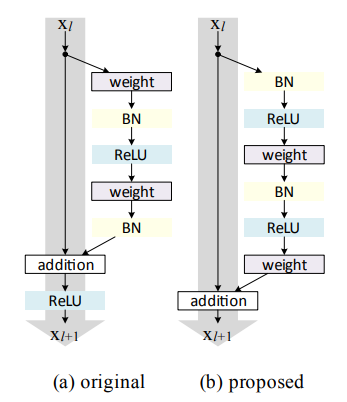

 Pre-activation 개념은 Identity Mappings in Deep Residual Networks 논문에서 제시되었는데요, 위 그림의 (b)에서 보듯 ReLU가 컨볼루션 블록 안으로 들어간 것을 의미합니다. 어떤 역할을 하는지에 대해서는 아래 자료를 참고합시다.

# 2) Growth Rate
특성 맵을 더해주던 ResNet과 달리 DenseNet에서는 특성 맵을 채널 방향으로 쌓아서 사용합니다. 그렇다면 4개의 채널을 가진 CNN 레이어 4개를 DenseNet 블록으로 만들었을 때, 입력값의 채널 개수가 4인 경우 블록 내 각 레이어의 입력값은 몇 개 채널을 가지게 될까요?

첫 번째 레이어 입력값의 채널은 입력 데이터의 채널 그대로 4입니다. 두 번째 레이어의 입력값은 입력 데이터의 채널 값과, 첫 번째 레이어 출력값의 채널인 4을 더해 8이 됩니다. 그리고 세 번째 레이어는 입력 데이터의 채널 4와 첫 번째 레이어 출력값의 채널 4, 그리고 두 번째 레이어 출력값의 채널 4를 받아 12개의 특성 맵을 입력받고, 네 번째 레이어는 같은 방식으로 16개의 특성 맵을 입력받습니다.

입력값의 채널이 4로 시작했으나 진행할수록 특성 맵의 크기가 매우 커지는 것을 볼 수 있습니다. 이를 제한하기 위해서 논문에서는 growth rate이라는 값을 조정하여 레이어를 거치면서 증가하게 되는 채널의 개수를 조절합니다.

위에서 CNN의 채널 수를 4로 정하였는데 이 값이 growth rate이라고 할 수 있습니다. 블록 내의 채널 개수를 작게 가져가면서 최종 출력값의 특성 맵 크기를 조정할 수 있도록 했다고 합니다. 이외에도 여러 방식이 적용되었으니 DenseNet Tutorial 1 Paper Review & Implementation details 에서 bottleneck 레이어, transition 레이어, composite function 등에 대해 살펴보고 넘어가시기 바랍니다.

이미지넷 챌린지에 참가하기 위한 DenseNet 구현체는 growth rate로 32를 사용했다고 합니다. 입력값으로 사용되는 이미지넷 데이터에는 3개의 채널이 있고, 이러한 Dense Block 내에 12개의 컨볼루션 레이어가 있을 때 각 레이어에서 입력받는 채널은 몇 개가 될까요? 하단 코드 블록에 파이썬을 사용해 배열로 나타내고 실행하여 결과를 출력해 봅시다.

In [1]:
# Q. Dense Block내의 각 레이어 output의 channel을 계산하는 함수를 적어보세요.
def get_channel_list():
    channel_list = []
    input_channel = 32
    growth_rate = 32
    for i in range(12):
        channel_list.append(input_channel + growth_rate*i)
    return channel_list

get_channel_list()
# 결과가 [32, 64, 96, 128, 160, 192, 224, 256, 288, 320, 352, 384] 이 나오면 정상적으로 구현된 것입니다.

[32, 64, 96, 128, 160, 192, 224, 256, 288, 320, 352, 384]

# ResNet 이후 시도 (2) 어떤 특성이 중요할까?
네트워크 구조를 연달아 다루어 조금 질리실 수 있을 것 같습니다. 이제 마지막 네트워크, SENet 을 살펴보겠습니다. SENet은 Squeeze-and-Excitation Networks의 줄임말인데요. 어떤 것을 "squeeze and excite" 한다는 것일까요?

일반적인 CNN은 입력에 대해서 컨볼루션 필터를 필터 사이즈(filter size)에 따라 적용합니다. 이때 필터의 개수가 곧 컨볼루션 레이어 출력값의 채널 개수가 됩니다. SqueezeNet에서는 이때 채널 방향으로 global average pooling을 적용, 압축된 정보를 활용하여 중요한 채널이 활성화되도록 합니다. 어떻게 보면 CNN에서 나온 특성 맵의 채널에 어텐션(attention) 매커니즘을 적용한 블록을 만들어냈다고 볼 수 있습니다. 이런 SENet은 2017 ILSVRC 분류 문제(classification task)에서 1등을 하게 됩니다.

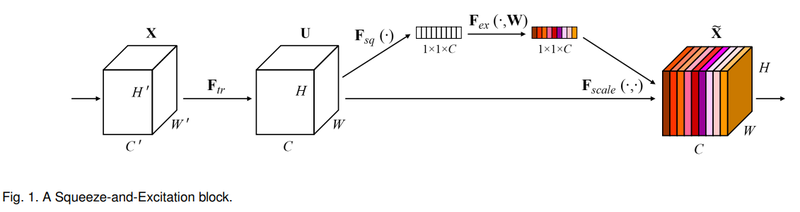


1) Squeeze
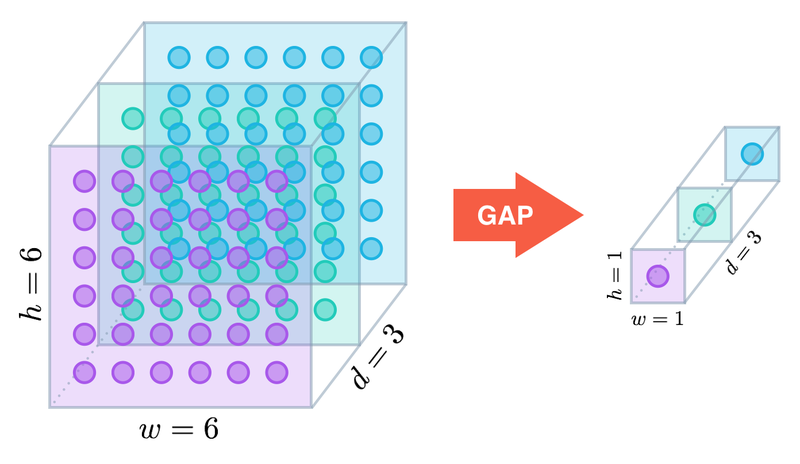

[GAP(Global Average Pooling) 과정]

Squeeze 는 말 그대로 특성에서 중요한 정보를 짜내는 과정입니다. 특성 맵의 채널에서 어느 채널이 중요한지 정보를 만들기 위해서는 우선 채널에 따른 정보를 압축해서 가져와야 하겠지요.

어떻게 채널별 정보를 압축할 수 있을까요? 일반 CNN에서도 많이 사용하듯, 풀링(pooling) 기법을 사용하면 됩니다. 풀링은 보통 커널(kernel) 영역의 정보를 압축하는 데 사용하지요. 커널 영역에 대해 최댓값만 남기는 것이 Max Pooling, 평균값을 남기는 것이 Average Pooling이었습니다.
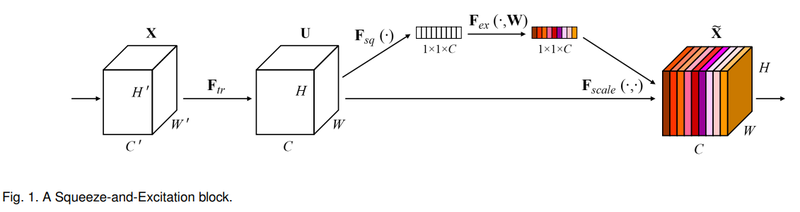

다시 한번 그림을 살펴볼까요? 여기서 "Squeeze"는 
F
s
q
F 
s
​
 q함수에서 일어납니다. 
F
t
r
F 
t
​
 r이라는 컨볼루션 레이어를 거치면 "HxWxC"의 크기를 가진 특성 맵 U 가 나옵니다. U 에 Squeeze를 적용하면 "1x1xC"의 크기가 나오게 됩니다. 벡터의 차원으로 보실 수 있듯이 각 채널별로 딱 1개의 숫자만 남도록 2D 특성맵 전체에 대해 평균값을 남기는 global average pooling을 수행했습니다. 이렇게 얻어진 "1x1xC"의 벡터는 채널별 정보를 압축해 담고 있습니다


2) Excitate
채널별 정보를 짜내는 데 성공했습니다. 이제 채널별 정보에 따라 어떤 채널을 강조해야 할지 판단하면 됩니다.

채널을 강조하는 것을 논문에서는 "excitation"으로 표현하며, 수식은 다음과 같습니다. 이전에 봤던 전체 네트워크 그림의 
F
e
x
F 
ex
​
 식이지요.
 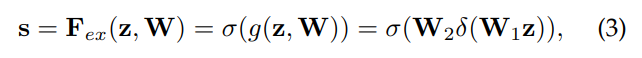

 z 는 위에서 global average pooling을 적용한 특성, 즉 "squeeze" 활동의 결과물입니다.
이 특성에 
W
1
W 
1
​
 을 곱해주는 linear 레이어를 거치고 ReLU 활성화 함수 δ 를 거칩니다.
이후 두 번째 
W
2
W 
2
​
 를 곱해주는 linear layer를 거치고 마지막으로 시그모이드 활성화 함수 σ을 거칩니다.

 이때 시그모이드를 사용하는 이유는 가장 중요한 하나의 채널만 활성화되는 것이 아닌, 여러 채널들이 서로 다른 정도로 활성화되도록 하기 위함입니다. 데이터셋에 정답 라벨이 하나뿐인 단순 분류 모델의 활성화 함수로는 소프트맥스(SoftMax)를 사용해서 단 하나의 최댓값을 찾지만, 하나의 대상에도 여러 개의 클래스의 정답 라벨을 지정할 수 있는 다중 라벨 분류(multi label classification)에서는 시그모이드를 사용하는 것과 같은 방식입니다.

 이렇게 계산된 벡터를 기존의 특성 맵에 채널에 따라서 곱해주어 중요한 채널이 활성화 되도록 만들어줍니다.

 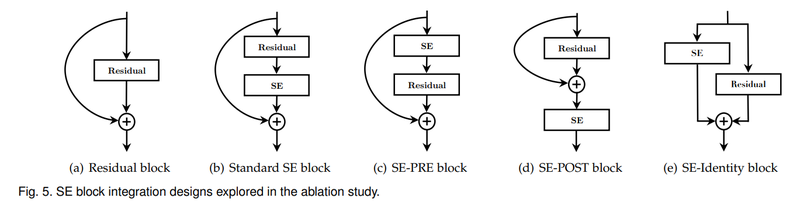

 5가지 구조 중에서 가장 성능이 좋았던 결합 방식은 SE-Identity block과 SE-PRE block

# 모델 최적화하기 (1) Neural Architecture Search

지금까지 봤던 방법은 사람이 고안한 방식을 네트워크 구조에 적용하여 효과를 봤던 방법입니다. 모델의 훈련은 컴퓨터가 시켜줄 수 있어도, 어떤 모델 구조가 좋을지는 사람이 직접 고민하고 실험해 보아야 했죠. 이렇게 새로운 모델 구조를 고안하고 이해하는 과정을 반복하다 보면, "우리가 딥러닝으로 이미지 분류 문제를 풀기 위해 딥러닝 모델의 파라미터(parameter)를 최적화해 왔듯이 모델의 구조 자체도 최적화할 수는 없을지" 생각하게 됩니다. 이렇게 여러 가지 네트워크 구조를 탐색하는 것을 아키텍쳐 탐색(architecture search)라고 합니다. 그리고 그중 신경망을 사용해 모델의 구조를 탐색하는 접근 방법을 NAS(neural architecture search) 라고 합니다.

NASNet은 NAS에 강화학습을 적용하여 500개의 GPU로 최적화한 CNN 모델들인데요. 직접 모델 탐색을 할 환경을 구축하지 않더라도 텐서플로우에서 이미지넷 2012년 데이터셋에 최적화된 구조의 pre-trained NASNet 모델을 쉽게 사용할 수 있습니다 (참고). 그렇다면 NasNet은 어떤 방법으로 만들어졌는지 대략적으로 살펴보도록 합시다.

1) NASNet
NASNet과 같이 거창한 방법이 아니더라도, 일반적으로 머신 러닝에서는 그리드 탐색(grid search) 등으로 실험과 모델 셋팅(config)를 비교하기 위한 자동화된 방법을 사용하곤 합니다. 그리드 탐색은 간단히 말하면 모든 조합을 실험해보는 것입니다. 그러나 그리드 탐색과 같은 방법으로 접근할 경우 모델에서 바꿔볼 수 있는 구성의 종류가 매우 많아 머신 러닝 중에서도 학습이 오래 걸리는 딥러닝에서는 적합하지 않습니다.

딥러닝에서 모델을 탐색하기 위해 강화학습 모델이 대상 신경망의 구성(하이퍼파라미터)을 조정하면서 최적의 성능을 내도록 하는 방법이 제안되었으며, NASNet은 그중 하나입니다. 아키텍쳐 탐색을 하는 동안 강화학습 모델은 대상 신경망의 구성을 일종의 변수로 조정하면서 최적의 성능을 내도록 합니다. 우리가 지금까지 보아왔던 레이어의 세부 구성, CNN의 필터 크기, 채널의 개수, connection 등이 조정할 수 있는 변수가 됩니다. 이렇게 네트워크 구성에 대한 요소들을 조합할 수 있는 범위를 탐색 공간(search space)이라고 합니다. 이 공간에서 최고의 성능을 낼 수 있는 요소의 조합을 찾는 것이지요.

NASNet이 NAS를 처음 적용한 것은 아니며 이전에도 논문들이 있었습니다. 이전의 방식들은 우리가 많이 접해왔던 MNIST에 최적화하는데 800개의 GPU를 사용해서 28일이 걸렸다고 합니다. 그렇게 나온 구조가 아래의 그림입니다.

NASNet 논문은 이미지넷 데이터에 대해 이보다 짧은 시간 안에 최적화를 했다고 합니다. 어떻게 한 것일까요?


#  Convolution cell
레이어 하나마다의 하이퍼 파라미터를 조절한다면 탐색 공간이 무지막지 방대해질 겁니다. 탐색 공간이 넓다는 말은 찾아야 할 영역이 넓다는 의미이고 넓은 곳에서 최적의 포인트를 찾는 데는 당연히 더 오랜 시간이 걸리겠죠. NASNet 논문에서는 이러한 탐색 공간을 줄이기 위해서 모듈(cell) 단위의 최적화를 하고 그 모듈을 조합하는 방식을 채택합니다.

ResNet에는 Residual Block, DenseNet에는 Dense Block이라는 모듈이 사용되는데, 논문에서는 이와 유사한 개념을 convolution cell이라고 부릅니다. Convolution cell은 normal cell과 reduction cell로 구분됩니다. Normal cell은 특성 맵의 가로, 세로가 유지되도록 stride를 1로 고정합니다. Reduction cell은 stride를 1 또는 2로 가져가서 특성 맵의 크기가 줄어들 수 있도록 합니다. 논문의 모델은 normal cell과 reduction cell 내부만을 최적화하며, 이렇게 만들어진 convolution cell이 위 그림의 두 가지입니다. 두 가지 cell을 조합해 최종 결과 네트워크(NASNet)를 만들었으며, 좀 더 적은 연산과 가중치로 SOTA(state-of-the-art) 성능을 기록했다고 하네요.
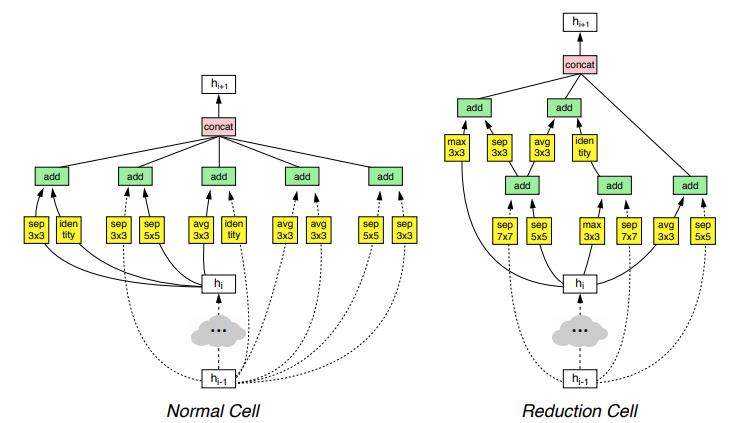

NASNet은 강화학습을 활용해 사람이 디자인하지 않고 컴퓨터(AI)가 스스로 탐색하여 찾아낸, 가성비(연산 효율)와 성능이 뛰어난 이미지 분류용 최적의 CNN 구조입니다.

조금 더 디테일하게 핵심 요소를 포함하여 요약하면 다음과 같습니다.

"강화학습을 기반으로 Normal/Reduction Cell이라는 모듈 단위를 자동으로 탐색·조합하여, 적은 연산량과 파라미터로도 SOTA(최고 수준) 성능을 낸 자율형 신경망 구조입니다."

# 모델 최적화하기 (2) EfficientNet
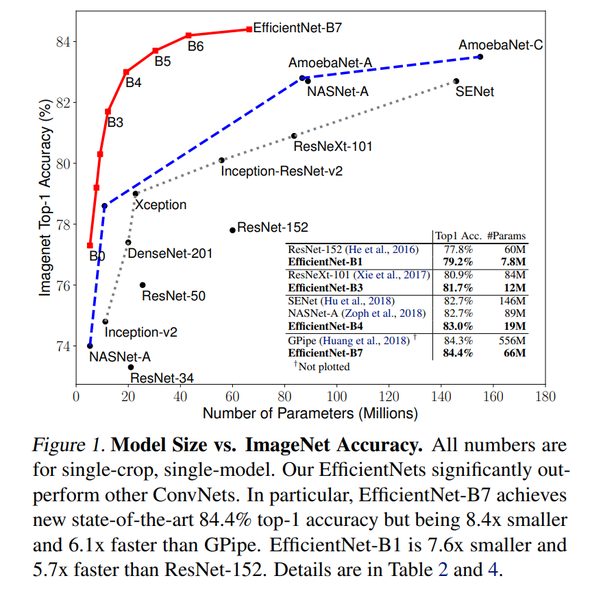

이번에 살펴볼 접근 방법은 2019년 발표된 EfficientNet입니다. EfficientNet의 강력함은 위의 그래프로 한눈에 볼 수 있습니다. 기존 모델들의 오류율을 뛰어넘을 뿐만 아니라 모델의 크기인 "Number of Parameters" 또한 최적화된 것을 볼 수 있습니다. 빨간색 선이 EfficientNet의 모델들이고 그 아래로 각 점에 따라서 이전에 봐왔던 모델들이 있는 것을 볼 수 있습니다. 정확도를 얻는 데 다른 네트워크들은 무지막지한 파라미터의 수를 사용한 반면 EfficientNet은 작고 효율적인 네트워크를 사용했다고 볼 수 있습니다.

EfficientNet은 우리가 이미지에 주로 사용하는 CNN을 효율적으로 사용할 수 있도록 네트워크의 형태를 조정할 수 있는 width, depth, resolution 세 가지 요소에 집중합니다. 여기서 width는 CNN의 채널에 해당합니다. 채널을 늘려줄수록 CNN의 파라미터와 특성을 표현하는 차원의 크기를 키울 수 있습니다. depth는 네트워크의 깊이입니다. ResNet은 대표적으로 네트워크를 더 깊게 만들 수 있도록 설계해 성능을 올린 예시입니다. 마지막으로 resolution은 입력값의 너비(w)와 높이(h) 크기입니다. 입력이 클수록 정보가 많아져 성능이 올라갈 여지가 생기지만 레이어 사이의 특성 맵이 커지는 단점이 있습니다.

Compound scaling
EfficientNet은 앞서 말한 resolution, depth, width를 최적으로 조정하기 위해서 앞선 NAS와 유사한 방법을 사용해 기본 모델(baseline network)의 구조를 미리 찾고 고정해둡니다. 모델의 구조가 고정이 되면 효율적인 모델을 찾는다는 커다란 문제가, 개별 레이어의 resolution, depth, width 를 조절해 기본 모델을 적절히 확장시키는 문제로 단순화됩니다.
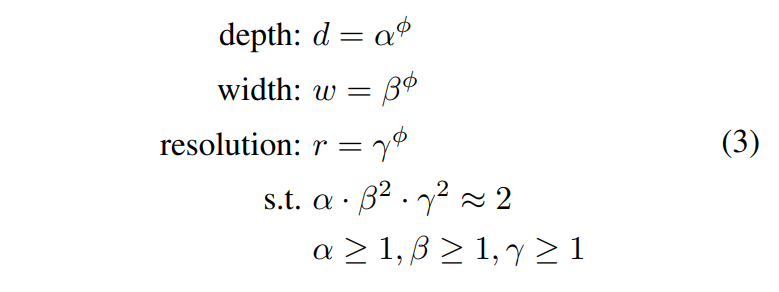

그리고 EfficientNet 논문에서는 resolution, depth, width라는 세 가지 "scaling factor"를 동시에 고려하는 compound scaling을 제안합니다. 위 식에서 compound coefficient ϕ는 모델의 크기를 조정하기 위한 계수가 됩니다. 위 식을 통해 레이어의 resolution, depth, width를 각각 조정하는 것이 아니라 고정된 계수 ϕ에 따라서 변하도록 하면 보다 일정한 규칙에 따라(in a principled way) 모델의 구조가 조절되도록 할 수 있습니다.

논문은 우선 ϕ를 1로 고정한 뒤 resolution과 depth, width을 정하는 α,β,γ의 최적값을 찾습니다. 논문에서는 앞서 설명했던 그리드 탐색으로 α,β,γ을 찾을 수 있었다고 설명합니다. 이후 α,β,γ, 즉 resolution과 depth, width의 기본 배율을 고정한 뒤 compound coefficient ϕ를 조정하여 모델의 크기를 조정합니다.


EfficientNet 논문에서 모델의 크기를 키우기 위해 제안한 핵심 방법은 복합 스케일링(Compound Scaling)입니다.

기존에는 모델의 성능을 높이기 위해 깊이(Depth), 너비(Width), 해상도(Resolution) 중 하나씩만 골라 키웠다면, EfficientNet은 이 세 가지 요소를 **고정된 규칙과 비율에 따라 동시에(In a principled way)** 키우는 방식을 사용합니다.

이를 구조화하여 정리하면 다음과 같습니다.

---

### 1. 스케일링의 3가지 핵심 요소

모델을 키울 때 직관적으로 조절할 수 있는 세 가지 변수를 정의합니다.

* **너비 (Width, $w$):** CNN의 채널(Channel) 수입니다. 채널이 많아질수록 더 미세한 특징을 표현할 수 있습니다.
* **깊이 (Depth, $d$):** 네트워크의 레이어(Layer) 수입니다. 레이어가 깊어질수록 더 복잡한 특징을 학습할 수 있습니다.
* **해상도 (Resolution, $r$):** 입력 이미지의 가로·세로 크기입니다. 해상도가 커질수록 이미지 내의 정밀한 정보가 보존됩니다.

### 2. 복합 스케일링(Compound Scaling)의 원리

세 요소가 서로 독립적이지 않고 연관되어 있다는 점에 주목하여, 다음과 같은 수식을 통해 모델을 확장합니다.

$$\text{depth: } d = \alpha^\phi$$

$$\text{width: } w = \beta^\phi$$

$$\text{resolution: } r = \gamma^\phi$$

$$\text{s.t. } \alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$$

$$\alpha \ge 1, \beta \ge 1, \gamma \ge 1$$

* **$\phi$ (Compound Coefficient):** 사용자가 제어하는 **모델 크기 조절 계수**입니다. 이 값을 키울수록 모델 전체가 일정한 비율로 커집니다.
* **$\alpha, \beta, \gamma$:** 각 요소가 커지는 **기본 배율**입니다. (너비와 해상도는 연산량(FLOPs)에 제곱 비례하므로 $\beta^2, \gamma^2$으로 제한을 둡니다.)

### 3. 실제 모델을 크게 만드는 2단계 과정

1. **상수($\alpha, \beta, \gamma$) 탐색:** 우선 모델 크기 계수인 $\phi$를 1로 고정해 둔 상태에서, 기본 모델(Baseline Network, 여기서는 NAS로 찾은 EfficientNet-B0)에 대해 그리드 탐색(Grid Search)을 수행하여 최적의 비율인 $\alpha, \beta, \gamma$ 값을 찾아냅니다.
2. **모델 확장 ($\phi$ 증가):** 찾아낸 최적의 배율 상수($\alpha, \beta, \gamma$)를 고정해 두고, 원하는 연산량과 모델 크기에 맞춰 **$\phi$만 증가시키며 모델을 순차적으로 키워나갑니다.** (이 과정을 통해 EfficientNet-B1부터 B7까지의 거대한 모델들이 만들어집니다.)

---

> **💡 한 줄 요약**
> EfficientNet은 모델의 **깊이, 너비, 해상도를 각각 따로 키우지 않고**, 미리 찾아둔 최적의 비율($\alpha, \beta, \gamma$)에 맞춰 **복합 계수($\phi$)를 증가시켜 세 요소를 동시에 일정하게 확장**하는 방식을 사용합니다.

# 1) 내가 하고싶은 분야 논문 찾아보기
# Seeing Beyond the Brain: Conditional Diffusion Model with Sparse Masked Modeling for Vision Decoding

## 요약
1. 🧠 MinD-Vis는 fMRI 뇌 활동을 기반으로 시각 자극을 디코딩하고 고품질의 의미적으로 정확한 이미지를 재구성하는 새로운 2단계 프레임워크를 제안합니다.
2. 💡 이 프레임워크는 대규모 fMRI 데이터에서 마스킹된 모델링을 통해 효과적인 뇌 표현을 학습하는 Sparse-Coded Masked Brain Modeling (SC-MBM) 단계와, 이 표현을 사용하여 강력한 이중 조건부 잠재 확산 모델(DC-LDM)로 이미지를 생성하는 단계를 포함합니다.
3. 🚀 MinD-Vis는 기존 최첨단 방법론보다 의미적 정확도와 생성 품질 면에서 크게 뛰어난 성능을 보이며, 심지어 피험자의 상상과 관련된 세부사항까지 디코딩할 수 있음을 입증했습니다.

## Abstract
이 논문은 뇌 활동 기록, 특히 fMRI 데이터를 사용하여 시각적 자극을 디코딩하고 재구성하는 "MinD-Vis: Sparse-Masked Brain Modeling with Double-Conditioned Latent Diffusion Model for Human Vision Decoding"이라는 새로운 프레임워크를 제안합니다. 이 연구는 인간의 시각 시스템에 대한 이해를 심화하고, Brain-Computer Interface를 통해 인간 시각과 컴퓨터 비전 간의 간극을 연결하는 것을 목표로 합니다.

**1. 문제 정의 및 동기 (Problem Definition and Motivation)**
fMRI 데이터로부터 고품질의 의미적으로 정확한 이미지를 재구성하는 것은 매우 어려운 문제입니다. 그 이유는 다음과 같습니다:
*   **복잡한 기저 표현 (Complex Underlying Representations)**: 뇌 신호는 매우 복잡한 정보를 담고 있습니다.
*   **데이터 주석 부족 (Scarcity of Data Annotations)**: fMRI-이미지 쌍 데이터셋이 매우 제한적입니다.
*   **fMRI 데이터 특성 (fMRI Data Characteristics)**:
    *   **공간적 중복성 (Spatial Redundancy)**: 인접한 fMRI 복셀들은 유사한 활동을 보여 공간적 중복성이 높습니다.
    *   **차원 불균형 (Dimensionality Gap)**: fMRI 데이터(수천 개의 복셀)는 이미지 데이터(수십만 개의 픽셀)보다 훨씬 낮은 차원을 가집니다.
    *   **개인별 차이 (Individual Variability)**: 동일한 시각 자극에 대한 뇌 활성화 패턴이 개인마다 크게 다릅니다.
*   **기존 방법의 한계 (Limitations of Conventional Methods)**: 재구성된 이미지가 흐릿하거나 의미적으로 무의미한 경우가 많았습니다.

이러한 문제들을 해결하기 위해, 대규모 데이터셋에서 표현 학습의 강점을 활용하고 뇌의 희소 코딩(sparse coding) 원리를 모방하는 MinD-Vis 프레임워크가 개발되었습니다.

**2. 핵심 방법론: MinD-Vis 프레임워크 (Core Methodology: MinD-Vis Framework)**
MinD-Vis는 두 가지 순차적인 단계로 구성됩니다:

**단계 A: SC-MBM (Sparse-Coded Masked Brain Modeling) - 뇌 특징 학습 (Brain Feature Learner)**
이 단계에서는 fMRI 데이터의 효과적인 자기 지도(self-supervised) 표현을 학습합니다.
*   **동기 (Motivation)**:
    *   fMRI 데이터의 공간적 중복성을 활용하여 마스크된 부분을 복구함으로써 깊은 문맥적 이해를 학습합니다.
    *   인간 뇌의 1차 시각 피질(primary visual cortex)에서 시각 정보가 희소하게(sparsely) 인코딩된다는 생물학적 원리(sparse coding)를 모방하여, 정보 전달 효율성을 높이고 최소한의 중복성을 만듭니다.
*   **방법론 (Methodology)**:
    1.  **패치화 및 임베딩 (Patchification and Embedding)**: 벡터화된 fMRI 복셀들을 패치로 나누고, 1D 컨볼루션 레이어를 사용하여 이 패치들을 고차원 임베딩으로 변환합니다. 여기서 중요한 것은 `embedding-to-patch-size ratio`를 매우 크게 설정한다는 점입니다 (예: 16 패치 사이즈당 1024 임베딩 차원). 이는 원본 데이터 공간보다 훨씬 큰 오버-컴플리트(over-complete)한 표현 공간을 생성하여 fMRI 표현의 정보 용량(information capacity)을 크게 증가시킵니다.
    2.  **마스킹 (Masking)**: fMRI 패치의 상당 부분(예: 75%)을 무작위로 마스킹합니다. fMRI 데이터의 높은 공간적 중복성 때문에, 큰 마스크 비율로도 유용한 정보를 학습할 수 있으며 계산량을 절약할 수 있습니다.
    3.  **비대칭 오토인코더 (Asymmetric Autoencoder)**:
        *   **인코더 (EMBM - Encoder for Masked Brain Modeling)**: 마스크되지 않은 패치들로부터 효과적인 fMRI 표현을 학습하는 데 최적화됩니다.
        *   **디코더 (DMBM - Decoder for Masked Brain Modeling)**: 마스크된 패치들을 복구하도록 훈련되며, 크기가 작고 나중에 폐기됩니다.
*   **결과 (Outcome)**: 이 단계는 fMRI 데이터를 locality constraints를 가진 희소 코딩된 표현으로 변환하며, 이는 이후 단계에서 시각 콘텐츠를 디코딩하는 데 사용됩니다.

**단계 B: DC-LDM (Double-Conditioned Latent Diffusion Model) - 이중 조건부 잠재 확산 모델 (Conditional Synthesis)**
이 단계에서는 사전 훈련된 fMRI 인코더를 LDM(Latent Diffusion Model)과 통합하여 이미지를 생성합니다.
*   **동기 (Motivation)**:
    *   fMRI-이미지 쌍 데이터의 제약 속에서 강력하고 일관된 이미지 생성이 필요합니다.
    *   일반적인 조건부 생성 모델과 달리, MinD-Vis는 샘플링 다양성(sampling diversity)보다 생성 일관성(generation consistency)을 중요하게 여깁니다. 유사한 뇌 활동에서 디코딩된 이미지는 의미적으로 유사해야 합니다.
*   **방법론 (Methodology)**:
    1.  **잠재 확산 모델 (Latent Diffusion Model, LDM)**: LDM은 원본 데이터 공간 대신 이미지의 저차원 잠재 공간에서 작동하여 계산 효율성을 높이고 고품질 이미지 합성을 가능하게 합니다.
    2.  **이중 조건화 (Double Conditioning)**: MinD-Vis는 fMRI 표현($\mathbf{z}$)을 LDM에 두 가지 방식으로 조건화합니다.
        *   **크로스-어텐션 헤드 (Cross-Attention Heads)**: LDM의 UNet 내부의 크로스-어텐션 메커니즘을 통해 조건부 정보가 적용됩니다. fMRI 인코더의 출력($\tau_{\theta}(\mathbf{z})$)이 LDM의 key($K$) 및 value($V$) 벡터로 주입됩니다.
        *   **타임 스텝 조건화 (Time Steps Conditioning)**: fMRI 인코더의 출력($\sigma_{\theta}(\tau_{\theta}(\mathbf{z}))$)이 LDM의 타임 스텝 임베딩에 추가됩니다. 이는 UNet의 중간 레이어에 영향을 미쳐 더욱 강력한 안내를 제공합니다.
        조건부 최적화 목표는 다음과 같습니다:
        $\mathcal{L}_{t}^{\text{cond}} = \mathbb{E}_{\mathbf{x}, \epsilon \sim \mathcal{N}(0,1), t} \left[ \left\| \epsilon - \epsilon_{\theta}(\mathbf{x}_t, t, \tau(\mathbf{z}), \sigma(\tau(\mathbf{z}))) \right\|^2_2 \right]$
        여기서 $\epsilon$은 예측된 노이즈, $\epsilon_{\theta}$는 노이즈 예측 함수(UNet), $\mathbf{x}_t$는 $t$ 스텝에서의 노이즈가 추가된 잠재 이미지, $\tau(\mathbf{z})$는 크로스-어텐션 조건, $\sigma(\tau(\mathbf{z}))$는 타임 스텝 조건입니다.
    3.  **파인튜닝 (Finetuning)**: SC-MBM으로 사전 훈련된 fMRI 인코더는 LDM과 통합되며, fMRI-이미지 쌍 데이터를 사용하여 공동으로 파인튜닝됩니다. 이 과정에서 fMRI 인코더와 크로스-어텐션 헤드가 최적화되며, 다른 LDM 부분은 고정됩니다.

**3. 실험 및 결과 (Experiments and Results)**
*   **데이터셋 (Datasets)**: HCP (Human Connectome Project), GOD (Generic Object Decoding Dataset), BOLD5000 (Brain, Object, Landscape Dataset)을 활용했습니다. HCP와 GOD는 사전 훈련에, GOD는 메인 파인튜닝에, BOLD5000은 검증 및 일반화 능력 평가에 사용되었습니다.
*   **평가 지표 (Evaluation Metrics)**:
    *   **N-way Classification Accuracy**: 재구성된 이미지의 의미적 정확성(semantic correctness)을 평가합니다. 사전 훈련된 ImageNet1K 분류기를 사용하여 재구성된 이미지와 Ground-Truth 이미지의 클래스 일치를 확인합니다.
    *   **FID (Fréchet Inception Distance)**: 이미지 생성 품질을 평가합니다.
*   **주요 결과 (Key Findings)**:
    *   **최첨단 성능 (State-of-the-Art Performance)**: MinD-Vis는 의미 매핑(100-way semantic classification)에서 66%, 생성 품질(FID)에서 41% 성능 향상을 달성하며 기존 방법론을 크게 능가했습니다.
    *   **의미적 정확성 및 상세성 (Semantic Accuracy and Detail)**: 기존 방법이 픽셀 수준의 유사성에 집중했던 것과 달리, MinD-Vis는 물결, 볼링공의 그림, 마차의 바퀴 등 의미적으로 정확하고 그럴듯한 세부 사항을 재구성합니다.
    *   **생성 일관성 (Generation Consistency)**: 동일한 fMRI 데이터를 다른 무작위 시드로 여러 번 디코딩했을 때, 재구성된 이미지가 형태, 색상, 질감, 의미 등에서 일관된 디테일을 보여주며 Ground-Truth와 잘 일치했습니다.
    *   **SC-MBM의 중요성 (Importance of SC-MBM)**: SC-MBM 사전 훈련 없이는 모델이 유의미한 이미지를 생성하지 못했으며, 사전 훈련이 효과적인 fMRI 표현 학습에 필수적임을 입증했습니다.
    *   **DC-LDM의 효과 (Effectiveness of DC-LDM)**: 이중 조건화는 단일 조건화에 비해 훨씬 높은 식별 정확도를 보이며 조건화 강도를 높이는 데 기여했습니다.
    *   **사전 훈련된 LDM의 영향 (Impact of Pre-trained LDM)**: ImageNet(레이블 조건화)으로 사전 훈련된 LDM이 가장 좋은 성능을 보였으며, 이는 제한된 훈련 쌍으로 더 간단한 조건화 잠재 공간에 적응하기 쉬웠음을 시사합니다.
    *   **일반화 능력 (Generalizability)**: BOLD5000 데이터셋에 대한 검증을 통해, MinD-Vis가 스캔 프로토콜 및 전처리 파이프라인이 다른 데이터셋에도 일반화될 수 있음을 보여주었습니다.
    *   **추가 기능 디코딩 (Decoding of Extra Features)**: 강, 푸른 하늘, 실내 장식과 같은 Ground-Truth에 없는 추가적인 세부 사항들이 디코딩되는 경우가 있었는데, 이는 피실험자의 마음속에 상상된 풍경이 fMRI에 반영되었을 가능성을 시사합니다.

**4. 한계 및 향후 연구 (Limitations and Future Work)**
*   **픽셀 수준의 안내 부족 (Lack of Pixel-level Guidance)**: 현재 MinD-Vis는 강력한 픽셀 수준의 안내가 부족하여 픽셀 수준 성능에 한계가 있습니다.
*   **해석 분석 부족 (Lack of Interpretation Analysis)**: MBM이 학습한 특징에 대한 생물학적 이해(biological understanding)가 부족합니다.
*   **개인 수준 디코딩 (Individual-level Decoding)**: 현재는 개인별 디코딩에 초점을 맞추고 있으나, 향후에는 교차-피실험자 일반화(cross-subject generalization) 및 시각 피질 외 다른 뇌 영역 통합 연구가 필요합니다.
*   **대규모 모델 탐색 (Exploration of Large-scale Models)**: MinD-Vis의 이단계 분리 설계는 인지 신경과학에서 최신 대규모 모델 및 표현 학습 기술의 잠재력을 탐색하는 길을 엽니다.

요약하자면, MinD-Vis는 희소 마스크 모델링을 통해 fMRI에서 효과적인 표현을 학습하고, 이중 조건부 잠재 확산 모델을 사용하여 매우 사실적이고 의미적으로 정확한 이미지를 재구성함으로써 시각 디코딩 분야의 상당한 발전을 이루었습니다.


In [ ]:
#